In [32]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [33]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [34]:
hek_airna_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0090_m6Afinal/pileup_strid.npz.genomic.pkl"
hek_airna_df = pd.read_pickle(hek_airna_df)

In [35]:
hela_airna_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver121224_mergedref_ON0091_m6Afinal/pileup_strid.npz.genomic.pkl"
hela_airna_df = pd.read_pickle(hela_airna_df)

In [36]:
hek_label_orig = pd.read_csv("/extdata3/baeklab/Jungmin/RNAmod/valid.new/cmp/glori.txt", sep="\t")
hela_label_orig = pd.read_csv("/extdata3/baeklab/Jungmin/RNAmod/valid.new/cmp/etam.txt", sep="\t")

In [37]:
new_dfs = []
for df in [hek_label_orig, hela_label_orig]:
    df = df.copy()
    df["genome_id"] = df["chr"] + ":" + df["str"].astype(str) + ":" + df["pos"].astype(str)
    df.rename(columns={"dom": "m6A_level", "depth": "exp_depth"}, inplace=True)
    df["m6a"] = (df["qval"] < 1E-7) & ~(df["qval_neg"] < 0.1)
    df["m6A_level"] = df["m6A_level"].clip(0, 1) * (df["m6a"].fillna(0))
    df = df[~((df["qval"] < 1E-1) & (df["qval"] >= 1E-7))]
    df = df[["genome_id", "m6A_level","exp_depth"]].fillna(0).copy()
    new_dfs.append(df)
hek_label, hela_label = new_dfs

In [38]:
print(hek_label)
print(hela_label)

               genome_id  m6A_level  exp_depth
0           chr1:+:14120        0.0        1.0
1           chr1:+:63441        0.0        1.0
3          chr1:+:184515        0.0        2.0
4          chr1:+:184761        0.0        1.0
5          chr1:+:268239        0.0       68.0
...                  ...        ...        ...
9977579  chrY:-:26627154        0.0       57.0
9977580  chrY:-:26628007        0.0        6.0
9977581  chrY:-:26628417        0.0       10.0
9977582  chrY:-:26628430        0.0        8.0
9977583  chrY:-:26630742        0.0       12.0

[9595968 rows x 3 columns]
               genome_id  m6A_level  exp_depth
0           chr1:+:52810        0.0        2.0
1           chr1:+:52816        0.0        2.0
2           chr1:+:52817        0.0        2.0
3          chr1:+:258784        0.0        7.0
4          chr1:+:258865        0.0        6.0
...                  ...        ...        ...
6944072  chrY:-:26627991        0.0        6.0
6944073  chrY:-:26627998        

In [39]:
hek_airna_df = hek_airna_df.reset_index(drop=True).merge(hek_label, on="genome_id", how="inner")

In [40]:
hela_airna_df = hela_airna_df.reset_index(drop=True).merge(hela_label, on="genome_id", how="inner")

In [41]:
print(hek_airna_df)
print(hela_airna_df)

               genome_id   gene_symbol  coding  isoforms      pm6a       dom  \
0        chr10:+:1000681        GTPBP4    True         3 -0.000000  0.004642   
1        chr10:+:1000683        GTPBP4    True         3  0.016154  0.013023   
2        chr10:+:1000685        GTPBP4    True         3 -0.000000  0.007298   
3        chr10:+:1000694        GTPBP4    True         3 -0.000000  0.006251   
4        chr10:+:1000701        GTPBP4    True         3  0.023575  0.007125   
...                  ...           ...     ...       ...       ...       ...   
8529613  chrY:-:11214291  LOC105379273   False         2  0.000000  0.000000   
8529614  chrY:-:11214493  LOC105379273   False         1  0.000000  0.000000   
8529615  chrY:-:11214525  LOC105379273   False         1  0.000000  0.000000   
8529616  chrY:-:21302687  LOC107987347   False         1  0.000000  0.000000   
8529617  chrY:-:21302708  LOC107987347   False         1  0.000000  0.000000   

         count_all  logsum_1_p_pos  kl_

In [42]:
def dom_threshold(df):
    return np.log10(0.02)*(df["dom"]) > df["logsum_1_p_pos"]/df["count_all"]

In [43]:
hek_airna_df["dom_threshold"] = dom_threshold(hek_airna_df)
hela_airna_df["dom_threshold"] = dom_threshold(hela_airna_df)

In [44]:
hek_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")

In [45]:
hela_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/reference_test/dorado_output.modkit.bed.m6A.genomic.pkl")

In [46]:
hek_dorado_df = hek_dorado_df.reset_index(drop=True).merge(hek_label, on="genome_id", how="inner")

In [47]:
hela_dorado_df = hela_dorado_df.reset_index(drop=True).merge(hela_label, on="genome_id", how="inner")

In [48]:
hek_m6anet_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/gene_df.pkl")
print(hek_m6anet_df)

                       genome_id   gene_symbol       dom      pm6a  count_dom  \
genome_id                                                                       
chr10:+:1000683  chr10:+:1000683        GTPBP4  0.014440  0.079608        277   
chr10:+:1000701  chr10:+:1000701        GTPBP4  0.121673  0.237195        263   
chr10:+:1000722  chr10:+:1000722        GTPBP4  0.015326  0.107223        261   
chr10:+:1000831  chr10:+:1000831        GTPBP4  0.111498  0.297641        287   
chr10:+:1000842  chr10:+:1000842        GTPBP4  0.042146  0.131331        261   
...                          ...           ...       ...       ...        ...   
chrY:-:11166816  chrY:-:11166816  LOC105379273  0.045455  0.257612         22   
chrY:-:11166858  chrY:-:11166858  LOC105379273  0.000000  0.068032         20   
chrY:-:11166906  chrY:-:11166906  LOC105379273  0.272727  0.604704         22   
chrY:-:11206471  chrY:-:11206471  LOC105379273  0.000000  0.053661         28   
chrY:-:11206478  chrY:-:1120

In [49]:
hela_m6anet_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0091/gene_df.pkl")
print(hek_m6anet_df)

                       genome_id   gene_symbol       dom      pm6a  count_dom  \
genome_id                                                                       
chr10:+:1000683  chr10:+:1000683        GTPBP4  0.014440  0.079608        277   
chr10:+:1000701  chr10:+:1000701        GTPBP4  0.121673  0.237195        263   
chr10:+:1000722  chr10:+:1000722        GTPBP4  0.015326  0.107223        261   
chr10:+:1000831  chr10:+:1000831        GTPBP4  0.111498  0.297641        287   
chr10:+:1000842  chr10:+:1000842        GTPBP4  0.042146  0.131331        261   
...                          ...           ...       ...       ...        ...   
chrY:-:11166816  chrY:-:11166816  LOC105379273  0.045455  0.257612         22   
chrY:-:11166858  chrY:-:11166858  LOC105379273  0.000000  0.068032         20   
chrY:-:11166906  chrY:-:11166906  LOC105379273  0.272727  0.604704         22   
chrY:-:11206471  chrY:-:11206471  LOC105379273  0.000000  0.053661         28   
chrY:-:11206478  chrY:-:1120

In [50]:
hek_m6anet_df = hek_m6anet_df.reset_index(drop=True).merge(hek_label, on="genome_id", how="inner")

In [51]:
hela_m6anet_df = hela_m6anet_df.reset_index(drop=True).merge(hela_label, on="genome_id", how="inner")

In [52]:
print(hek_m6anet_df)

              genome_id   gene_symbol       dom      pm6a  count_dom  \
0       chr10:+:1000683        GTPBP4  0.014440  0.079608        277   
1       chr10:+:1000701        GTPBP4  0.121673  0.237195        263   
2       chr10:+:1000722        GTPBP4  0.015326  0.107223        261   
3       chr10:+:1000831        GTPBP4  0.111498  0.297641        287   
4       chr10:+:1000842        GTPBP4  0.042146  0.131331        261   
...                 ...           ...       ...       ...        ...   
221473   chrX:-:7927320        PNPLA4  0.507937  0.765478         63   
221474   chrX:-:8565889         ANOS1  0.150000  0.388121         20   
221475   chrX:-:8570676         ANOS1  0.000000  0.028440        104   
221476  chrY:-:11166290  LOC105379273  0.000000  0.022205         34   
221477  chrY:-:11166315  LOC105379273  0.088235  0.177648         34   

        count_pm6a  coding  m6A_level  exp_depth  
0              277    True   0.000000     2034.0  
1              263    True   0.00

In [53]:
from scipy import stats

In [54]:

def plot_scatter(axes,r2_table,rho2_table,coord, df, x = "m6A_level", y = "dom", alpha=0.2, s = 10, noplot = False, bw_method = 0.2, sample = 1000):
    ax = axes[coord[0],coord[1]]
    plt.style.use('default')
    plt.style.use('seaborn-v0_8-white')
    sns.scatterplot(x=df[x], y=df[y], ax=ax, c="royalblue", s=s, legend=False, linewidth=0, alpha = alpha)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    r2 = stats.pearsonr(df[x], df[y])[0]**2
    rho2 = stats.spearmanr(df[x], df[y])[0]**2
    ## plot text in a white box
    ax.text(0.05, 0.95, f"R2: {r2:.3f}\nρ2: {rho2:.3f}", horizontalalignment='left', verticalalignment='top', transform=ax.transAxes, fontsize=24, bbox=dict(facecolor='white', alpha=0.5))
    r2_table[coord[0],coord[1]] = r2
    rho2_table[coord[0],coord[1]] = rho2
    return None

In [55]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})


In [56]:
cluster_df_glori = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/analyses/cluster_glori/glori_df.clustered.pkl")
cluster_df_etam = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/analyses/cluster_etam/etam_df.clustered.pkl")

In [57]:
cluster_df_glori["clustered"] = cluster_df_glori["nearest"] <= 20
cluster_df_etam["clustered"] = cluster_df_etam["nearest"] <= 20

In [58]:
hela_airna_df = hela_airna_df.merge(cluster_df_etam[["genome_id","clustered"]], on="genome_id", how="inner")
hela_m6anet_df = hela_m6anet_df.merge(cluster_df_etam[["genome_id","clustered"]], on="genome_id", how="inner")
hela_dorado_df = hela_dorado_df.merge(cluster_df_etam[["genome_id","clustered"]], on="genome_id", how="inner")
hek_airna_df =  hek_airna_df.merge(cluster_df_glori[["genome_id","clustered"]], on="genome_id", how="inner")
hek_m6anet_df = hek_m6anet_df.merge(cluster_df_glori[["genome_id","clustered"]], on="genome_id", how="inner")
hek_dorado_df = hek_dorado_df.merge(cluster_df_glori[["genome_id","clustered"]], on="genome_id", how="inner")

for df in [hela_airna_df, hela_m6anet_df, hela_dorado_df, hek_airna_df, hek_m6anet_df, hek_dorado_df]:
    df["clustered"] = df["clustered"].fillna(False)


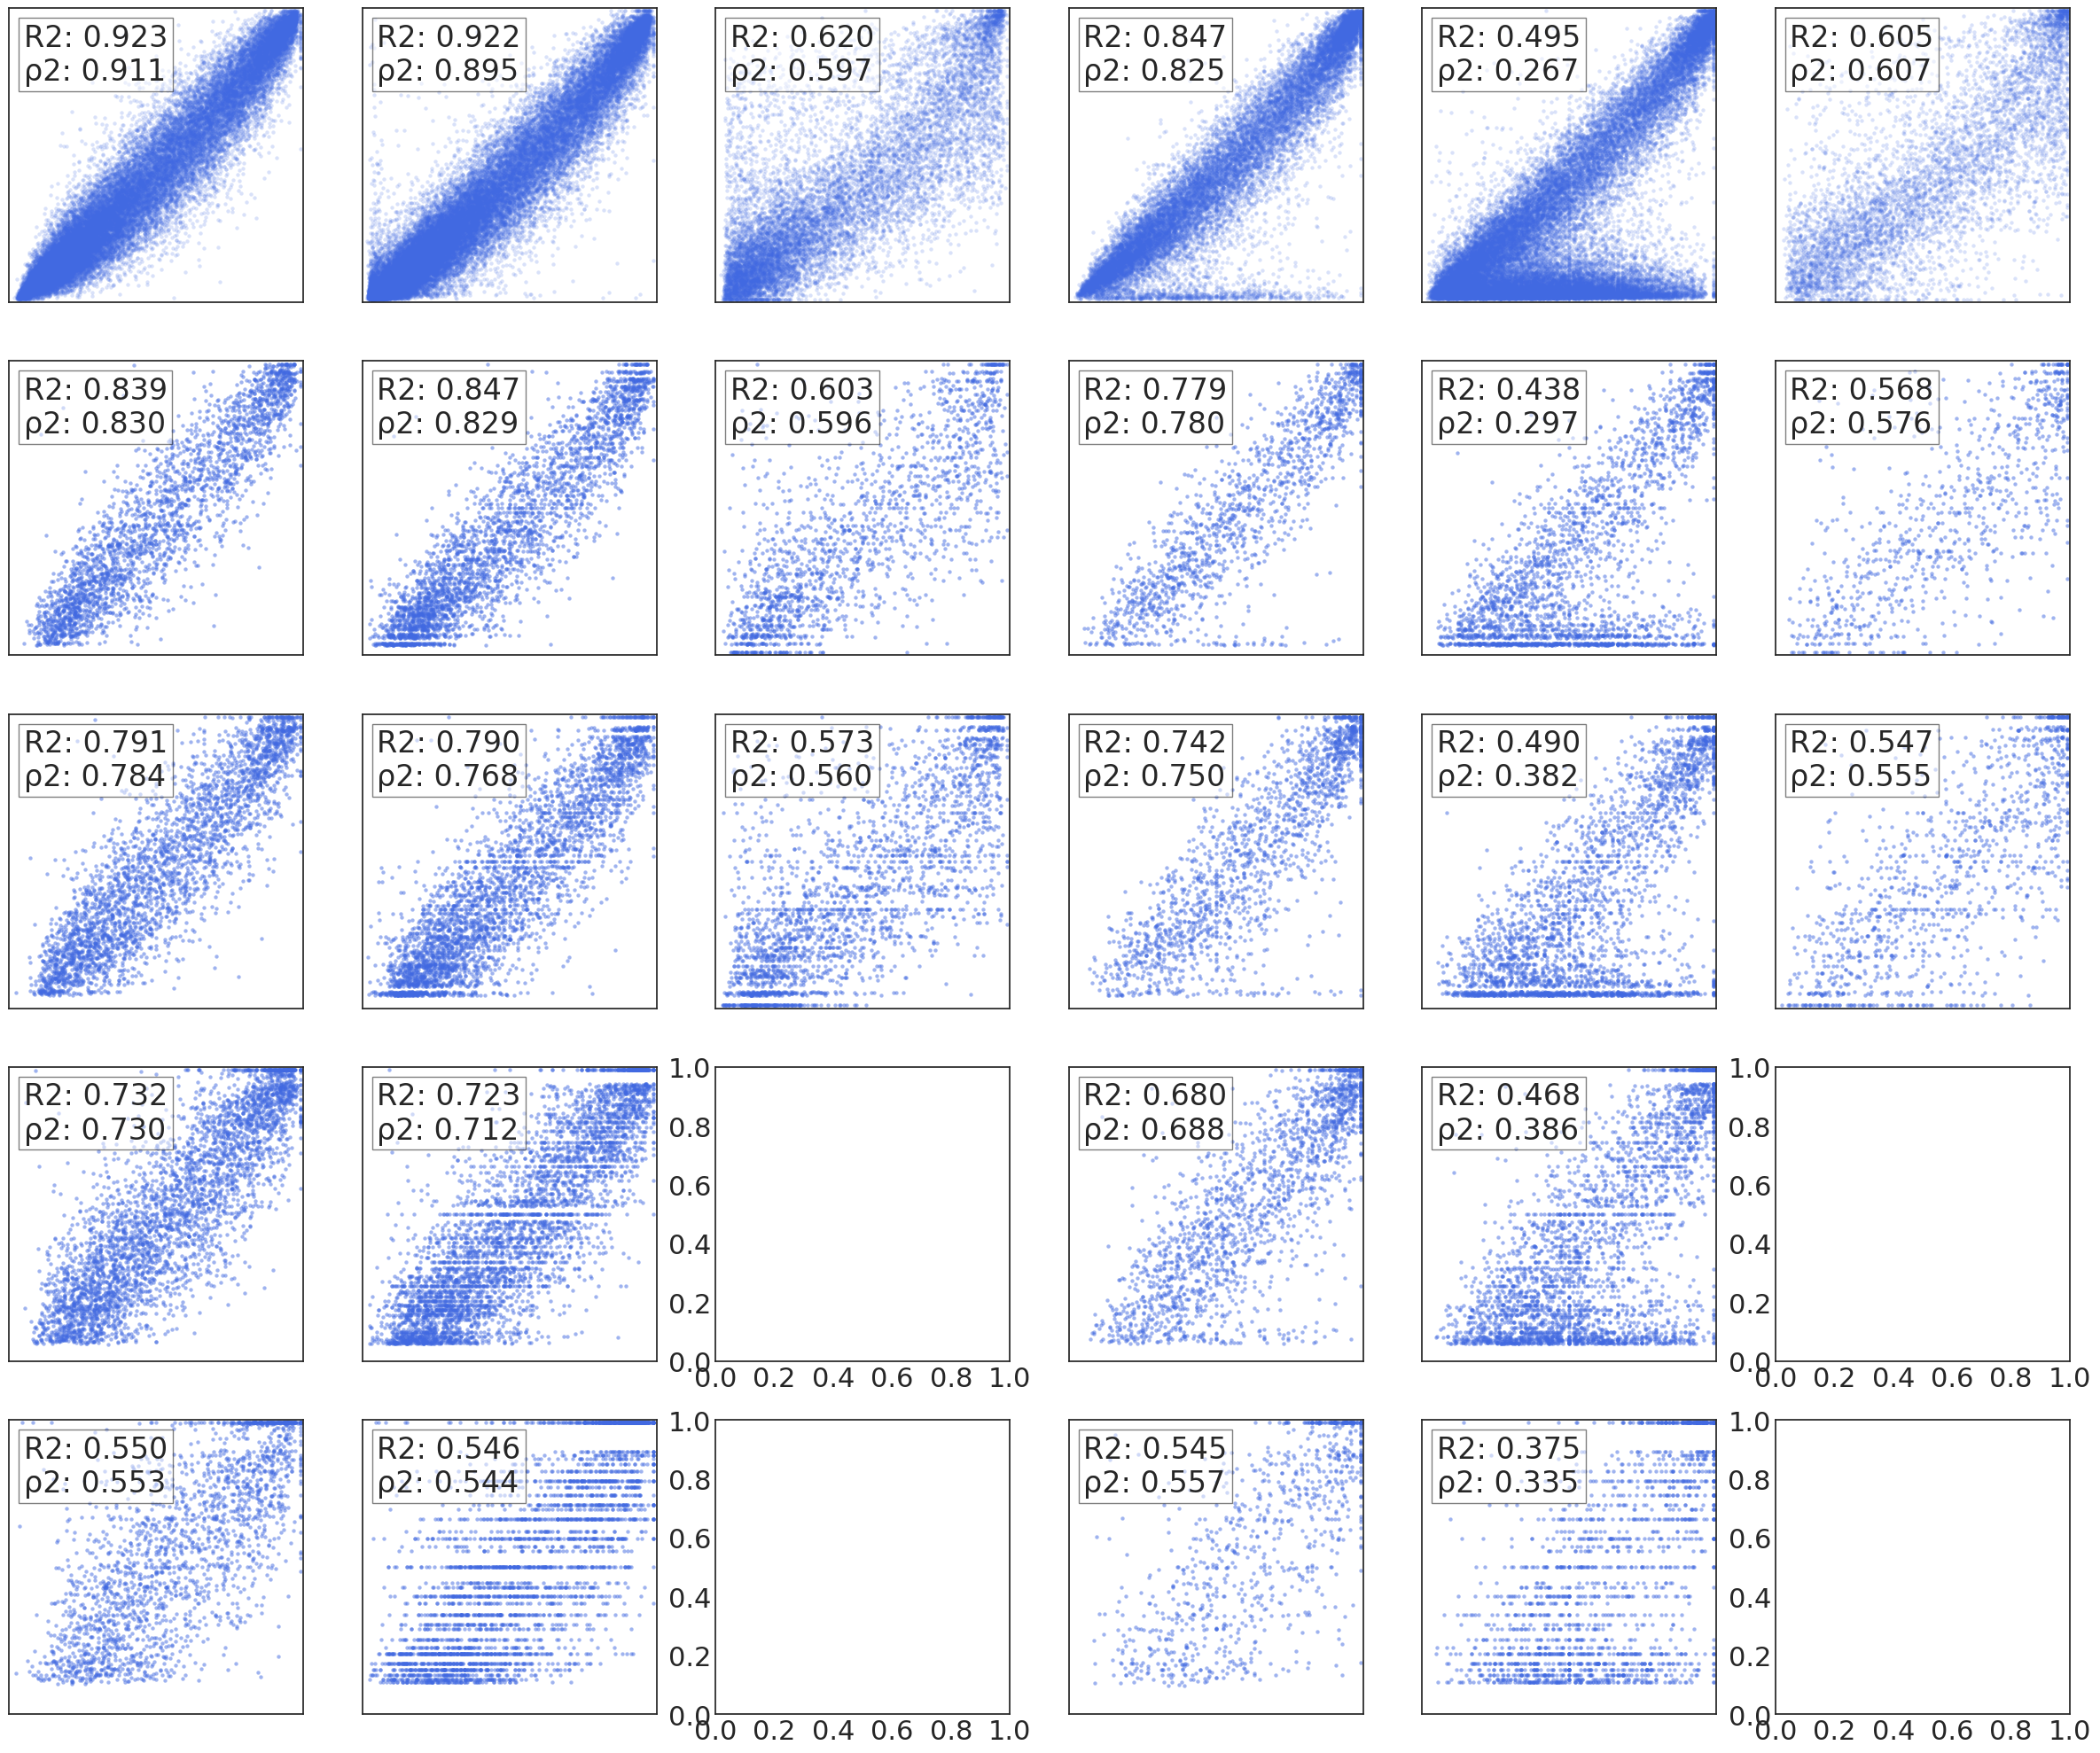

In [59]:
fig, axes = plt.subplots(5, 6, figsize=(30, 25))
df = hela_airna_df.fillna(0)
df = df[df["clustered"]]
r2_table = np.zeros((5,6))
rho2_table = np.zeros((5,6))
plot_scatter(axes,r2_table,rho2_table,[0,3],df[df["dom_threshold"] & (df["count_all"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,3],df[df["dom_threshold"] & (df["count_all"] > 30) & (df["count_all"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,3],df[df["dom_threshold"] & (df["count_all"] > 20) & (df["count_all"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,3],df[df["dom_threshold"] & (df["count_all"] > 10) & (df["count_all"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,3],df[df["dom_threshold"] & (df["count_all"] > 5) & (df["count_all"] <= 10)],  alpha = 0.5)

df = hek_airna_df.fillna(0)
df = df[df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,0],df[df["dom_threshold"] & (df["count_all"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,0],df[df["dom_threshold"] & (df["count_all"] > 30) & (df["count_all"] <= 40)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,0],df[df["dom_threshold"] & (df["count_all"] > 20) & (df["count_all"] <= 30)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,0],df[df["dom_threshold"] & (df["count_all"] > 10) & (df["count_all"] <= 20)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,0],df[df["dom_threshold"] & (df["count_all"] > 5) & (df["count_all"] <= 10)], alpha = 0.5)

df = hek_m6anet_df.fillna(0)
df = df[df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)],alpha = 0.5)

df = hela_m6anet_df.fillna(0)
df = df[df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)

df = hek_dorado_df.fillna(0)
df = df[df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,1],df[(df["dom"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,1],df[(df["dom"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,1],df[(df["dom"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,1],df[(df["dom"] > 0) & (df["count_dom"] > 10) & (df["count_dom"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,1],df[(df["dom"] > 0) & (df["count_dom"] >= 5) & (df["count_dom"] <= 10)], alpha = 0.5)

df = hela_dorado_df.fillna(0)
df = df[df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,4],df[(df["dom"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,4],df[(df["dom"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,4],df[(df["dom"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,4],df[(df["dom"] > 0) & (df["count_dom"] > 10) & (df["count_dom"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,4],df[(df["dom"] > 0) & (df["count_dom"] >= 5) & (df["count_dom"] <= 10)], alpha = 0.5)

plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/clustered_scatter")

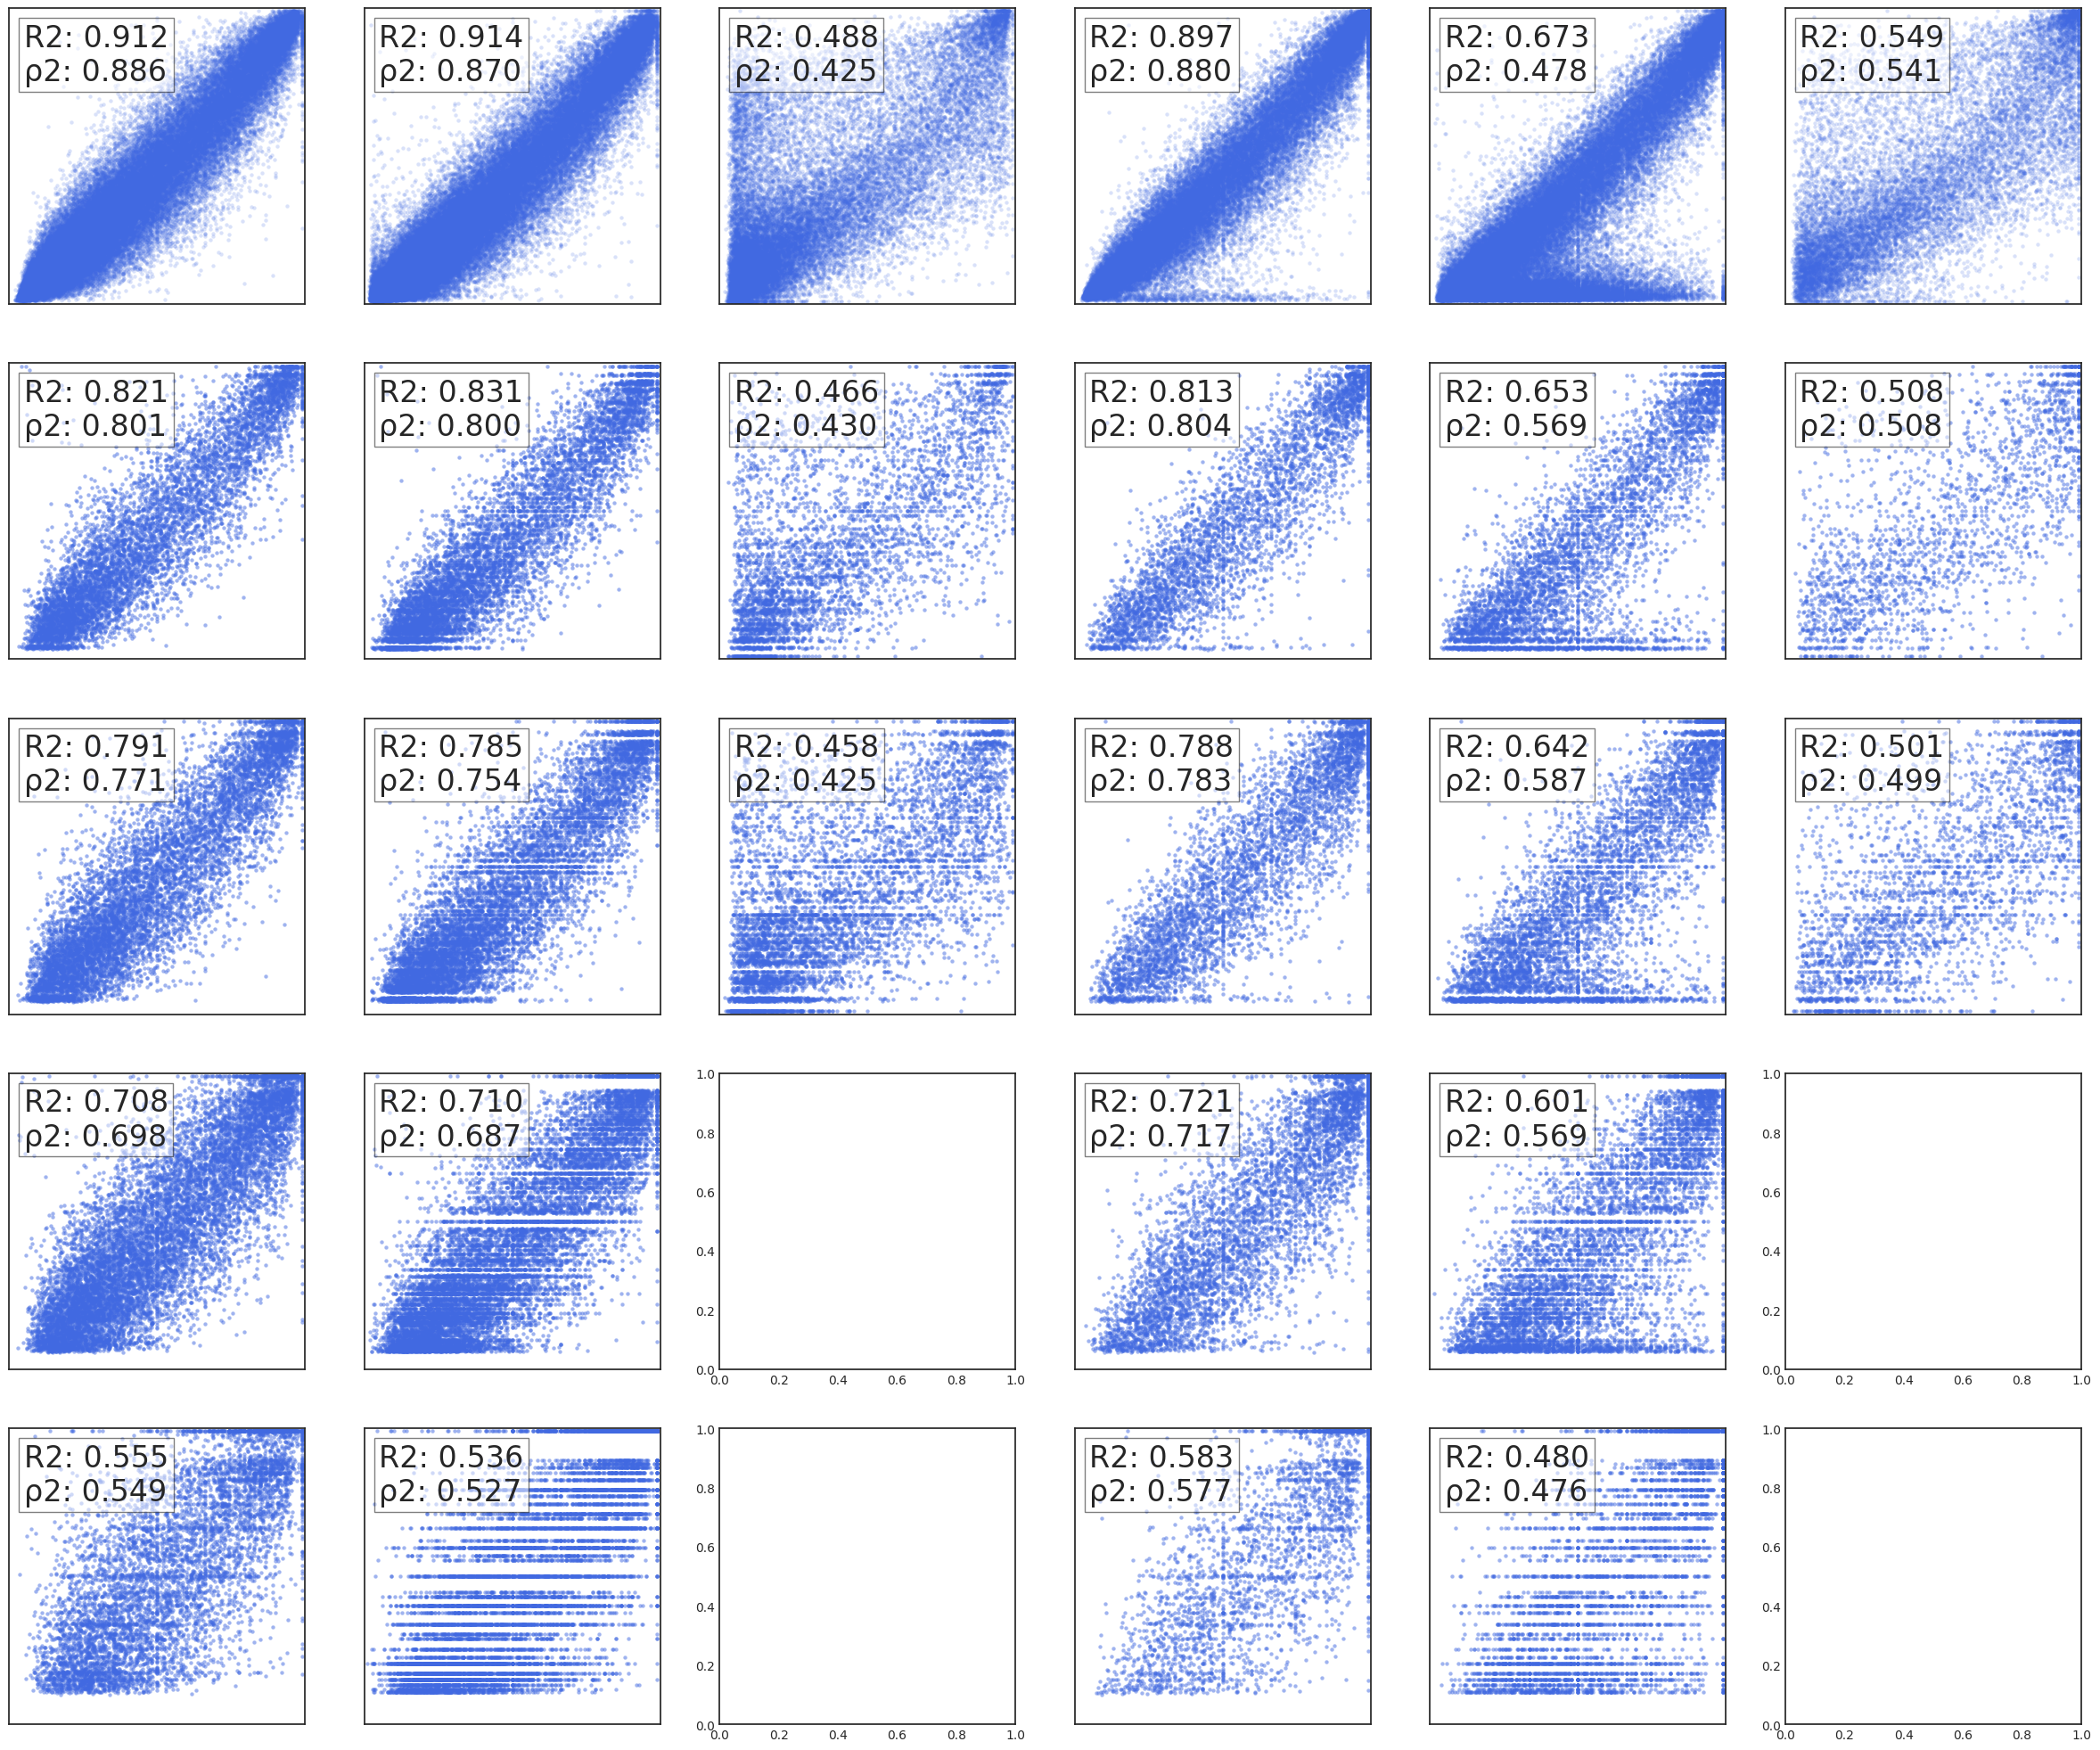

In [60]:
fig, axes = plt.subplots(5, 6, figsize=(30, 25))
df = hela_airna_df.fillna(0)
df = df[~df["clustered"]]
r2_table = np.zeros((5,6))
rho2_table = np.zeros((5,6))
plot_scatter(axes,r2_table,rho2_table,[0,3],df[df["dom_threshold"] & (df["count_all"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,3],df[df["dom_threshold"] & (df["count_all"] > 30) & (df["count_all"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,3],df[df["dom_threshold"] & (df["count_all"] > 20) & (df["count_all"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,3],df[df["dom_threshold"] & (df["count_all"] > 10) & (df["count_all"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,3],df[df["dom_threshold"] & (df["count_all"] > 5) & (df["count_all"] <= 10)],  alpha = 0.5)

df = hek_airna_df.fillna(0)
df = df[~df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,0],df[df["dom_threshold"] & (df["count_all"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,0],df[df["dom_threshold"] & (df["count_all"] > 30) & (df["count_all"] <= 40)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,0],df[df["dom_threshold"] & (df["count_all"] > 20) & (df["count_all"] <= 30)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,0],df[df["dom_threshold"] & (df["count_all"] > 10) & (df["count_all"] <= 20)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,0],df[df["dom_threshold"] & (df["count_all"] > 5) & (df["count_all"] <= 10)], alpha = 0.5)

df = hek_m6anet_df.fillna(0)
df = df[~df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)],alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,2],df[(df["pm6a"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)],alpha = 0.5)

df = hela_m6anet_df.fillna(0)
df = df[~df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,5],df[(df["pm6a"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)

df = hek_dorado_df.fillna(0)
df = df[~df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,1],df[(df["dom"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,1],df[(df["dom"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,1],df[(df["dom"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,1],df[(df["dom"] > 0) & (df["count_dom"] > 10) & (df["count_dom"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,1],df[(df["dom"] > 0) & (df["count_dom"] >= 5) & (df["count_dom"] <= 10)], alpha = 0.5)

df = hela_dorado_df.fillna(0)
df = df[~df["clustered"]]
plot_scatter(axes,r2_table,rho2_table,[0,4],df[(df["dom"] > 0) & (df["count_dom"] > 40)])
plot_scatter(axes,r2_table,rho2_table,[1,4],df[(df["dom"] > 0) & (df["count_dom"] > 30) & (df["count_dom"] <= 40)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[2,4],df[(df["dom"] > 0) & (df["count_dom"] > 20) & (df["count_dom"] <= 30)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[3,4],df[(df["dom"] > 0) & (df["count_dom"] > 10) & (df["count_dom"] <= 20)], alpha = 0.5)
plot_scatter(axes,r2_table,rho2_table,[4,4],df[(df["dom"] > 0) & (df["count_dom"] >= 5) & (df["count_dom"] <= 10)], alpha = 0.5)

plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/singleton_scatter")